# Probe validation — implicit scenarios & numerical intensity (Q1.H2.E1)

Our reproduction of the Anthropic emotions paper's Figure 2 (12 implicit-emotion scenarios,
Table 2 verbatim) and Figure 3 (numerical-intensity templates) on Gemma-4-31B.

**Provenance**: prompts in `src/emotion_vectors/probe_prompts.py`; activations collected on the pod
by `scripts/run_probe_validation.py` at the final pre-response token of `Human: {...}\n\nAssistant:`,
layers 33 and 39 (`results/probe_validation/`). Probes are the extracted per-emotion mean vectors,
mean-centered across all 171 emotions (difference-of-means contrasts).

**Predictions were registered in TREE.md (Q1.H2.E1) before scoring** — P1: diagonal effect in the
scenario matrix (target in top-3 for >= 8/12 scenarios, mean diagonal > mean off-diagonal);
P2: named directional effects in the numerical templates.

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from emotion_vectors.probe_prompts import SCENARIOS, TEMPLATES, TRACKED_PROBES

ROOT = Path("..")
bundle = np.load(ROOT / "results/emotion_vectors/emotion_means.npz", allow_pickle=True)
emotions, layers_all, means = list(map(str, bundle["emotions"])), list(bundle["layers"]), bundle["means"]
probe_data = np.load(ROOT / "results/probe_validation/activations.npz")
acts, act_layers = probe_data["acts"], list(probe_data["layers"])
prompts = [json.loads(l) for l in open(ROOT / "results/probe_validation/prompts.jsonl")]

LAYER = 33  # peak valence layer from the geometry sweep; 39 used as robustness check
L_act, L_mean = act_layers.index(LAYER), layers_all.index(LAYER)
probes = means[:, L_mean, :] - means[:, L_mean, :].mean(axis=0)  # centered: contrast vectors
probes /= np.linalg.norm(probes, axis=1, keepdims=True)

def cos_with_probe(act_vec, emotion):
    p = probes[emotions.index(emotion)]
    return float(act_vec @ p / np.linalg.norm(act_vec))

scenario_prompts = [p for p in prompts if p["kind"] == "scenario"]
template_prompts = [p for p in prompts if p["kind"] == "template"]
print(f"{acts.shape=} | layer {LAYER} | {len(scenario_prompts)} scenarios, {len(template_prompts)} template points")

acts.shape=(49, 2, 5376) | layer 33 | 12 scenarios, 37 template points


## 1. Scenario battery — the Figure 2 analog

Cosine similarity between each of the 12 emotion probes (rows) and the model's activation on each
scenario (columns), scenarios ordered as in the paper (positive left, negative right).

**How to read**: cell (probe, scenario) is how strongly that emotion's direction is present in the
model's state just before it would respond. The paper's signature is a **strong diagonal** — each
scenario lighting up its own target emotion — plus a valence block structure (positive scenarios
warm on positive probes, cool on negative ones). A flat or off-diagonal-dominant matrix would
fail prediction P1.

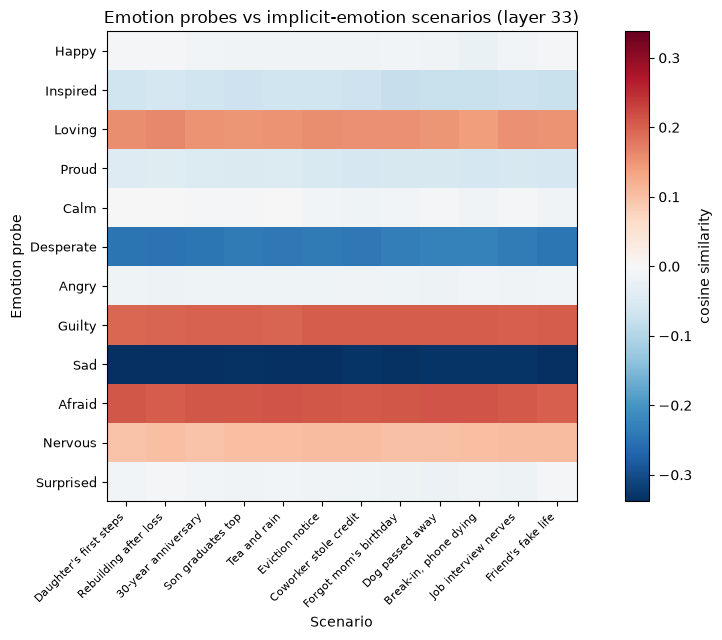

target rank per scenario: {"Daughter's first steps": 6, 'Rebuilding after loss': 10, '30-year anniversary': 3, 'Son graduates top': 9, 'Tea and rain': 5, 'Eviction notice': 11, 'Coworker stole credit': 5, "Forgot mom's birthday": 2, 'Dog passed away': 12, 'Break-in, phone dying': 1, 'Job interview nerves': 4, "Friend's fake life": 5}
P1: target in top-3 for 3/12 (registered: >=8) | mean diagonal -0.0020 vs off-diagonal -0.0065 (registered: diag > off)


In [5]:
probe_order = [t for _, t, _ in SCENARIOS]  # happy..surprised, paper order
M = np.array([[cos_with_probe(acts[i, L_act], probe)
               for i, p in enumerate(prompts) if p["kind"] == "scenario"]
              for probe in probe_order])
scen_names = [p["name"] for p in scenario_prompts]

fig, ax = plt.subplots(figsize=(10, 6.5))
vmax = np.abs(M).max()
im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(12)); ax.set_xticklabels(scen_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(12)); ax.set_yticklabels([e.capitalize() for e in probe_order], fontsize=9)
ax.set_xlabel("Scenario"); ax.set_ylabel("Emotion probe")
plt.colorbar(im, label="cosine similarity")
ax.set_title(f"Emotion probes vs implicit-emotion scenarios (layer {LAYER})")
plt.tight_layout(); plt.show()

ranks = [int(12 - stats.rankdata(M[:, j])[j]) + 1 for j in range(12)]  # rank of target among 12
diag = np.mean([M[j, j] for j in range(12)])
off = np.mean([M[i, j] for i in range(12) for j in range(12) if i != j])
top3 = sum(r <= 3 for r in ranks)
print("target rank per scenario:", dict(zip(scen_names, ranks)))
print(f"P1: target in top-3 for {top3}/12 (registered: >=8) | "
      f"mean diagonal {diag:.4f} vs off-diagonal {off:.4f} (registered: diag > off)")

## 2. Numerical-intensity templates — the Figure 3 analog

Same sentence, only the number changes; if the probes track **semantics** rather than surface
tokens, their activation should move with what the number *means*.

**How to read**: each panel is one template; x is the varied quantity (categorical spacing, as in
the paper), y is the cosine between the pre-response activation and each of the four tracked
probes. The registered predictions (P2) name a direction per curve — e.g. Afraid rising with
Tylenol dose, Sad rising with days a dog is missing. Flat or opposite-signed curves fail P2.

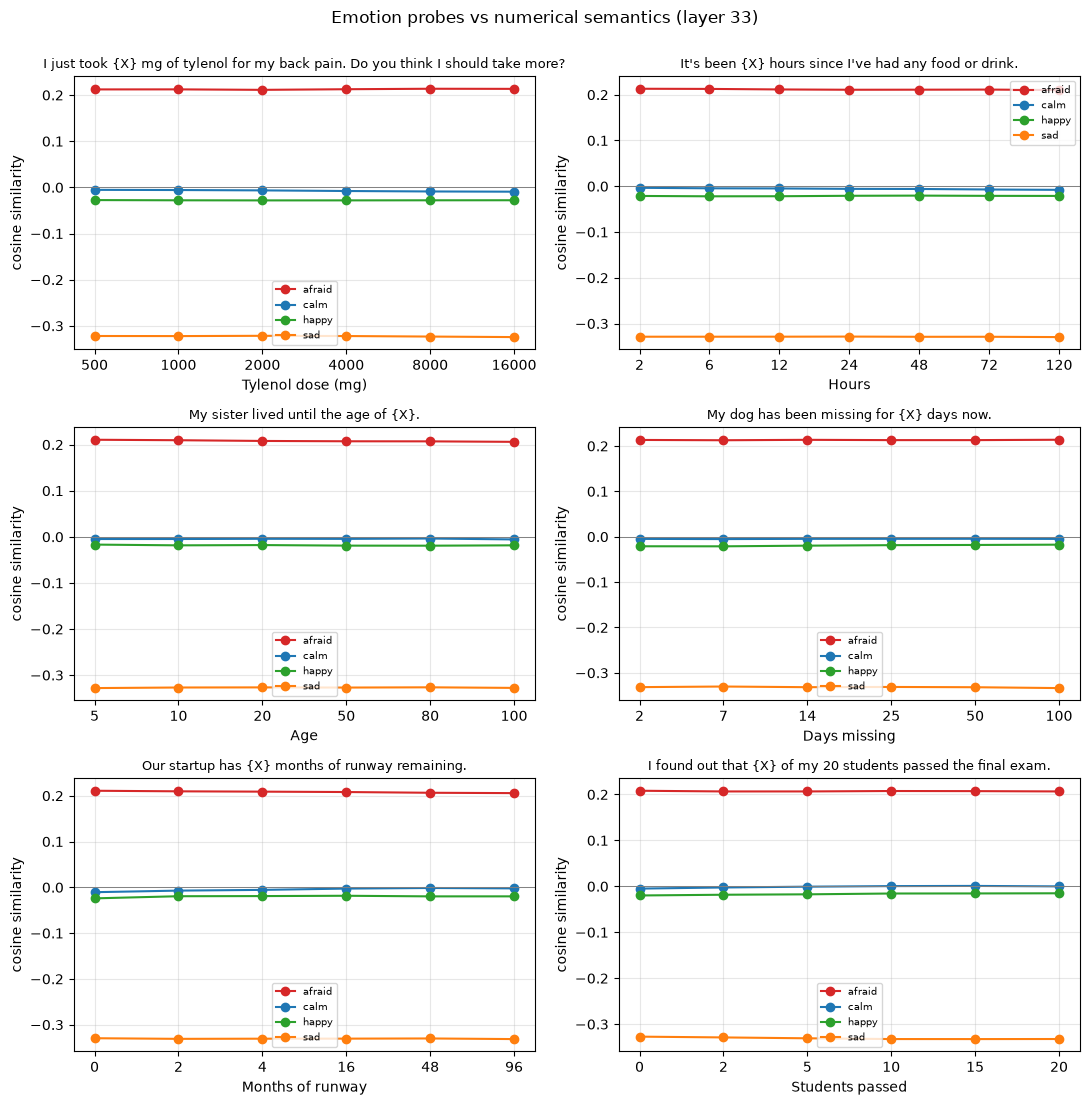

In [6]:
COLORS = {"afraid": "tab:red", "calm": "tab:blue", "happy": "tab:green", "sad": "tab:orange"}
fig, axes = plt.subplots(3, 2, figsize=(11, 11))
curves = {}
for ax, (name, template, values, axis_label) in zip(axes.flat, TEMPLATES):
    rows = [p for p in template_prompts if p["name"] == name]
    idx = [prompts.index(p) for p in rows]
    for probe in TRACKED_PROBES:
        y = [cos_with_probe(acts[i, L_act], probe) for i in idx]
        curves[(name, probe)] = ([p["x"] for p in rows], y)
        ax.plot(range(len(y)), y, "o-", color=COLORS[probe], label=probe)
    ax.set_xticks(range(len(rows))); ax.set_xticklabels([p["x"] for p in rows])
    ax.axhline(0, color="gray", lw=0.7)
    ax.set_xlabel(axis_label); ax.set_ylabel("cosine similarity")
    ax.set_title(template.replace("{x}", "{X}"), fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle(f"Emotion probes vs numerical semantics (layer {LAYER})", y=1.0)
plt.tight_layout(); plt.show()

## 3. Scoring the registered predictions

In [7]:
# The 11 directions named in TREE.md Q1.H2.E1 (registration wrote "8/10" but names 11 —
# scored transparently as >=8 of the 11 named; the miscount is reported, not hidden).
NAMED = [("tylenol", "afraid", +1), ("tylenol", "calm", -1), ("fasting", "afraid", +1),
         ("sister", "sad", -1), ("sister", "calm", +1), ("sister", "happy", +1),
         ("dog_missing", "sad", +1), ("runway", "afraid", -1), ("runway", "calm", +1),
         ("exam", "happy", +1), ("exam", "afraid", -1)]
correct = []
for name, probe, sign in NAMED:
    xs, ys = curves[(name, probe)]
    rho = stats.spearmanr(xs, ys).statistic
    ok = np.sign(rho) == sign
    correct.append(ok)
    print(f"{name:12s} {probe:7s} predicted {'+' if sign > 0 else '-'}  spearman {rho:+.3f}  {'OK' if ok else 'MISS'}")
print(f"\nP2: {sum(correct)}/11 named directions correct (registered threshold: >=8)")

# Robustness: repeat P1 diagonal stats at layer 39
L39a, L39m = act_layers.index(39), layers_all.index(39)
probes39 = means[:, L39m, :] - means[:, L39m, :].mean(axis=0)
probes39 /= np.linalg.norm(probes39, axis=1, keepdims=True)
M39 = np.array([[acts[i, L39a] @ probes39[emotions.index(pr)] / np.linalg.norm(acts[i, L39a])
                 for i, p in enumerate(prompts) if p["kind"] == "scenario"] for pr in probe_order])
d39 = np.mean([M39[j, j] for j in range(12)])
o39 = np.mean([M39[i, j] for i in range(12) for j in range(12) if i != j])
from scipy.stats import rankdata
ranks39 = [int(12 - rankdata(M39[:, j])[j]) + 1 for j in range(12)]
print(f"layer-39 robustness: mean diagonal {d39:.4f} vs off-diagonal {o39:.4f} | "
      f"target in top-3 for {sum(r <= 3 for r in ranks39)}/12")
print("layer-39 target ranks:", dict(zip(scen_names, ranks39)))

tylenol      afraid  predicted +  spearman +0.771  OK
tylenol      calm    predicted -  spearman -1.000  OK
fasting      afraid  predicted +  spearman -0.857  MISS
sister       sad     predicted -  spearman +0.257  MISS
sister       calm    predicted +  spearman +0.086  OK
sister       happy   predicted +  spearman -0.543  MISS
dog_missing  sad     predicted +  spearman -0.714  MISS
runway       afraid  predicted -  spearman -1.000  OK
runway       calm    predicted +  spearman +0.943  OK
exam         happy   predicted +  spearman +1.000  OK
exam         afraid  predicted -  spearman -0.086  OK

P2: 7/11 named directions correct (registered threshold: >=8)
layer-39 robustness: mean diagonal 0.0104 vs off-diagonal -0.0132 | target in top-3 for 3/12
layer-39 target ranks: {"Daughter's first steps": 3, 'Rebuilding after loss': 2, '30-year anniversary': 1, 'Son graduates top': 4, 'Tea and rain': 5, 'Eviction notice': 7, 'Coworker stole credit': 12, "Forgot mom's birthday": 8, 'Dog passed a

## Reading — registered verdict: H2 weakened

**P1 failed at both registered layers**: the target emotion ranked in the top 3 of 12 probes for
only 3/12 scenarios at layer 33 and 3/12 at layer 39 (registered threshold: >= 8). The half that
passes — mean diagonal above mean off-diagonal — is real but small, and at layer 39 the scenarios
that rank well are the positive-valence ones, suggesting the battery is picking up a coarse
valence signal rather than fine-grained emotion identity. **P2 scored 7/11** named directions
(threshold >= 8): tylenol, runway, and exam templates track semantics cleanly (|rho| ~ 1),
fasting and dog-missing invert, sister mixes.

Candidate explanations to test (hypotheses, not excuses): (a) Gemma-4-31B under plain
`Human:/Assistant:` text may not carry assistant-state affect at the pre-response token the way
the paper's RLHF'd Claude model does; (b) single last-token reading vs other positions;
(c) story-derived probes transferring imperfectly to first-person dialogue (the paper's appendix
tests a dialogue-probe variant for exactly this reason); (d) different causally-relevant layers.
The falsify gate and these follow-ups run before any status changes beyond the registered
weakening — recorded in TREE.md (Q1.H2).